In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/tanzania.csv",low_memory=False
)
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16


In [4]:
# Add new columns
df["Country"]="Tanzania"
df["Date"]= pd.to_datetime(df["YEAR"]* 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["Date"].dt.month
df.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,27.56,29.52,26.22,3.30,7.24,80.97,4.68,6.01,100.52,18.61,Tanzania,2015-01-01,1
1,2015,2,27.59,29.99,25.92,4.07,3.40,79.63,4.48,5.28,100.52,18.31,Tanzania,2015-01-02,1
2,2015,3,27.47,29.29,26.25,3.04,7.17,80.02,4.91,5.99,100.56,18.30,Tanzania,2015-01-03,1
3,2015,4,27.28,29.17,25.96,3.21,16.07,81.78,4.88,6.07,100.47,18.52,Tanzania,2015-01-04,1
4,2015,5,26.68,27.83,25.84,1.99,18.83,82.99,4.17,5.98,100.43,18.16,Tanzania,2015-01-05,1


In [5]:
df= df.replace(-999, np.nan)
df.duplicated().sum()

np.int64(0)

No duplicated row was found

In [6]:
df.isna().sum()

YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

No missing value was found

In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.802422,29.163493,25.03813,4.125363,3.740256,77.128038,4.105370,5.189248,100.801130,16.923683,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,22.680000,25.410000,20.03000,0.940000,0.000000,60.060000,1.120000,1.550000,100.150000,11.380000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.670000,28.090000,23.71000,3.330000,0.110000,73.167500,3.410000,4.377500,100.570000,15.340000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.990000,29.080000,25.37500,4.220000,0.640000,76.585000,4.190000,5.250000,100.760000,17.220000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.900000,30.170000,26.31000,4.940000,3.790000,81.100000,4.830000,5.980000,101.040000,18.420000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.970000,33.930000,28.01000,7.590000,122.650000,91.100000,8.400000,11.740000,101.510000,21.510000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.325388,1.371155,1.53544,1.102831,8.003947,5.070501,1.059803,1.215018,0.284461,1.881741,NaN,3.477046


The Tanzania dataset shows a warm and humid climate, with average temperatures around 26.8°C and relatively small temperature variation (range ≈ 4.1°C), indicating stable daily conditions. Rainfall is more frequent and intense than in drier regions (mean ≈ 3.74, max ≈ 122.65) with high humidity (~77%), suggesting a tropical climate with regular rain and occasional heavy downpours.

In [8]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore, nan_policy='omit')

outliers = (np.abs(z_scores) > 3)

outlier_count = outliers.sum()

outlier_count

T2M             1
T2M_MAX         2
T2M_MIN         4
PRECTOTCORR    81
RH2M            2
WS2M            8
WS2M_MAX        4
dtype: int64

In [9]:
import numpy as np
import pandas as pd

# make copy
df_cleaned = df.copy()

# -----------------------------
# 1. DEFINE COLUMN GROUPS
# -----------------------------
temp_cols = ["T2M", "T2M_MAX", "T2M_MIN", "T2M_RANGE"]
wind_cols = ["WS2M", "WS2M_MAX"]
other_cols = ["RH2M", "PS", "QV2M"]

# -----------------------------
# 2. CLIP ONLY STABLE FEATURES
# -----------------------------
for col in temp_cols + wind_cols + other_cols:
    lower = df_cleaned[col].quantile(0.01)
    upper = df_cleaned[col].quantile(0.99)
    df_cleaned[col] = df_cleaned[col].clip(lower=lower, upper=upper)

# -----------------------------
# 3. HANDLE RAINFALL PROPERLY
# -----------------------------

# (a) Add rain indicator
df_cleaned["RAIN_FLAG"] = (df_cleaned["PRECTOTCORR"] > 0).astype(int)

# (b) Log transform (NO clipping before this)
df_cleaned["PRECTOTCORR"] = np.log1p(df_cleaned["PRECTOTCORR"])

# (c) Optional: very light clipping after transform
upper = df_cleaned["PRECTOTCORR"].quantile(0.999)
df_cleaned["PRECTOTCORR"] = df_cleaned["PRECTOTCORR"].clip(upper=upper)

# -----------------------------
# 4. SAVE FILE
# -----------------------------
df_cleaned.to_csv("../data/tanzania_clean.csv", index=False)

print("Cleaning completed successfully.")

Cleaning completed successfully.


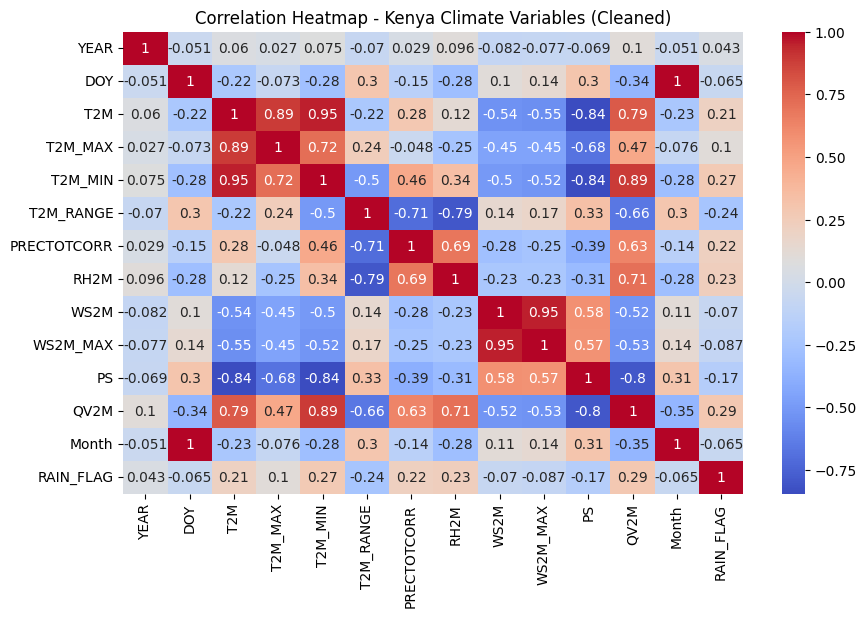

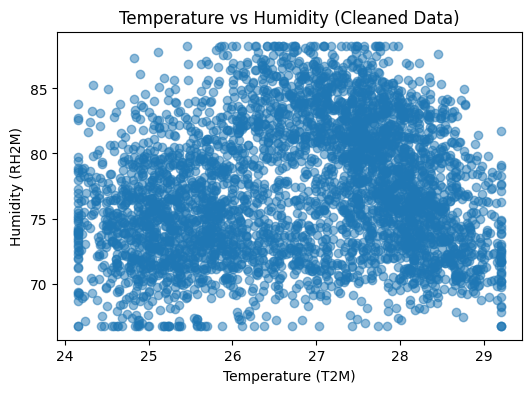

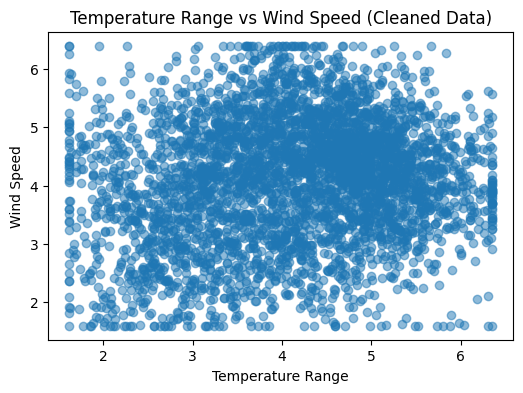

In [10]:

# Correlation heatmap
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation heatmap (CLEANED DATA)
plt.figure(figsize=(10,6))
sns.heatmap(df_cleaned.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap - Kenya Climate Variables (Cleaned)")
plt.show()

# Scatter plot
plt.figure(figsize=(6,4))
plt.scatter(df_cleaned["T2M"], df_cleaned["RH2M"], alpha=0.5)
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.title("Temperature vs Humidity (Cleaned Data)")
plt.show()

plt.figure(figsize=(6,4))
plt.scatter(df_cleaned["T2M_RANGE"], df_cleaned["WS2M"], alpha=0.5)
plt.xlabel("Temperature Range")
plt.ylabel("Wind Speed")
plt.title("Temperature Range vs Wind Speed (Cleaned Data)")
plt.show()

In [12]:
df_cleaned["PRECTOTCORR"].describe()

count    4108.000000
mean        0.920065
std         0.988982
min         0.000000
25%         0.104360
50%         0.494696
75%         1.566530
max         4.459882
Name: PRECTOTCORR, dtype: float64

The mean (~0.92) and median (~0.49) show a reduced right-skew, meaning extreme rainfall values are no longer dominating the distribution.
The range (0 to ~4.46) is now compact and stable, making it suitable for machine learning models while still preserving rainfall variation patterns..

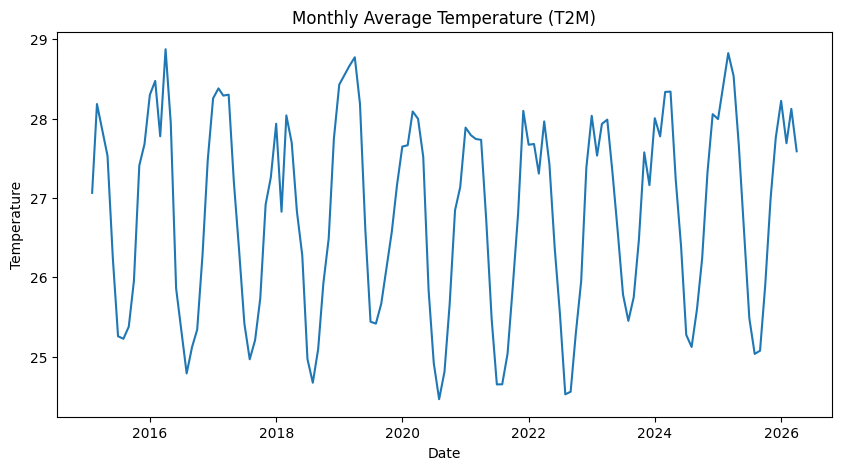

In [13]:
#T2m
import matplotlib.pyplot as plt

# ensure datetime
df_cleaned["Date"] = pd.to_datetime(df_cleaned["Date"])

# set index for resampling
df_ts = df_cleaned.set_index("Date")

# monthly average temperature
monthly_temp = df_ts["T2M"].resample("ME").mean()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp)
plt.title("Monthly Average Temperature (T2M)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.show()

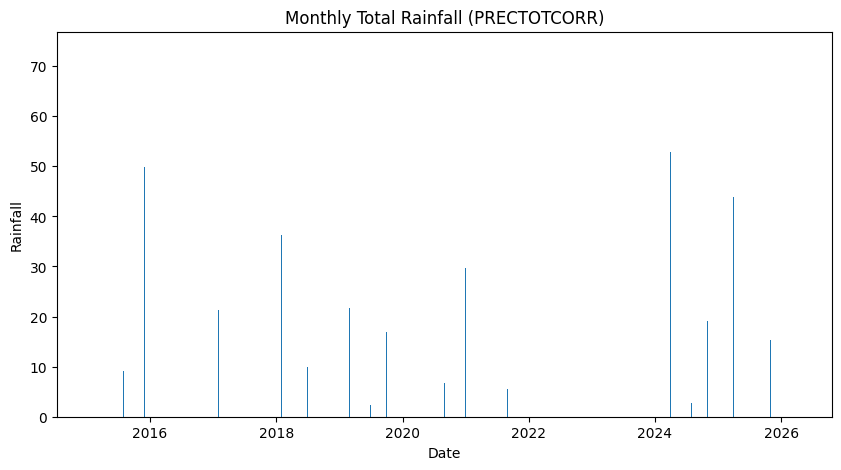

In [14]:
# Rain fall
monthly_rain = df_ts["PRECTOTCORR"].resample("ME").sum()

plt.figure(figsize=(10,5))
plt.bar(monthly_rain.index, monthly_rain)
plt.title("Monthly Total Rainfall (PRECTOTCORR)")
plt.xlabel("Date")
plt.ylabel("Rainfall")
plt.show()

In [15]:
# cleaned correlation
corr = df_cleaned.corr(numeric_only=True)

# unstack and sort correlations
corr_pairs = corr.unstack().sort_values(ascending=False)

# remove self-correlation
corr_pairs = corr_pairs[corr_pairs < 1]

print("Top Correlations:")
print(corr_pairs.head(10))

Top Correlations:
DOY       Month       0.996557
Month     DOY         0.996557
WS2M      WS2M_MAX    0.951705
WS2M_MAX  WS2M        0.951705
T2M_MIN   T2M         0.950670
T2M       T2M_MIN     0.950670
QV2M      T2M_MIN     0.889744
T2M_MIN   QV2M        0.889744
T2M_MAX   T2M         0.889115
T2M       T2M_MAX     0.889115
dtype: float64


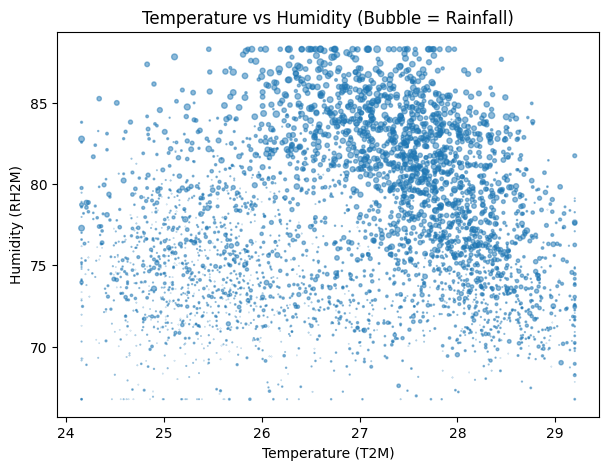

In [16]:
# bubble
plt.figure(figsize=(7,5))

plt.scatter(
    df_cleaned["T2M"],
    df_cleaned["RH2M"],
    s=df_cleaned["PRECTOTCORR"] * 5,
    alpha=0.5
)

plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Humidity (RH2M)")
plt.show()